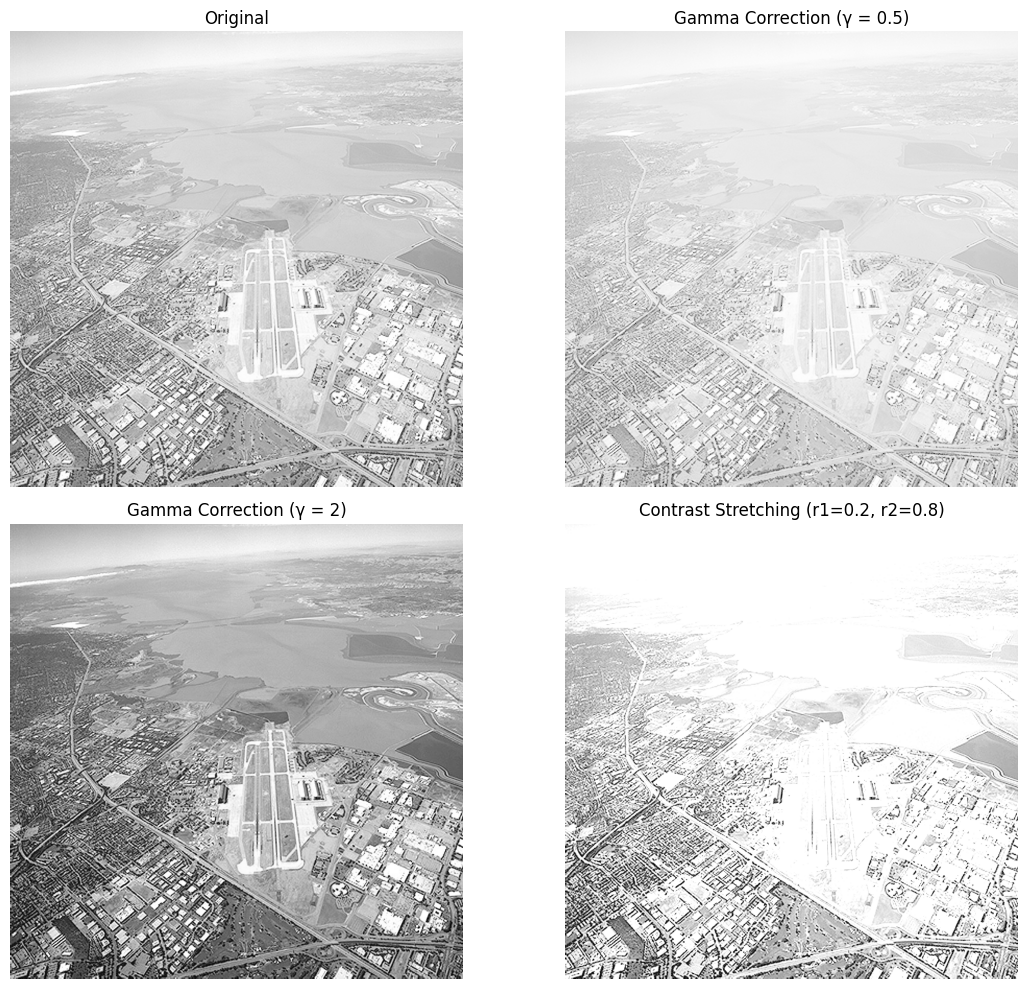

True

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


def gamma_correction(image, gamma):
    #Convert image values from [0,255] to [0,1]
    normalized = image / 255.0
    #Apply gamma correction
    corrected = np.power(normalized, gamma)
    #Convert back to [0,255]
    output = np.uint8(corrected * 255)
    return output


def contrast_stretch(image, r1=0.2, r2=0.8):
    #Normalize image to [0,1]
    img = image / 255.0
    #Create empty output image
    out = np.zeros_like(img, dtype=np.float32)

    #Set pixels below r1 to 0 (dark)
    out[img < r1] = 0
    #Stretch values between r1 and r2
    mask = (img >= r1) & (img <= r2)
    out[mask] = (img[mask] - r1) / (r2 - r1)
    #Set pixels above r2 to 1 (bright)
    out[img > r2] = 1

    # Convert back to [0,255]
    return np.uint8(out * 255)


#Path to input image
image_path = "/content/runway.png"

#Read image in grayscale
img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)

#Check if image loaded correctly
if img is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

#Apply transformations
gamma_05 = gamma_correction(img, 0.5)
gamma_2 = gamma_correction(img, 2.0)
contrast_img = contrast_stretch(img, 0.2, 0.8)

#Display results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#Original image
axes[0, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

#Gamma 0.5
axes[0, 1].imshow(gamma_05, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Gamma Correction (γ = 0.5)")
axes[0, 1].axis("off")

#Gamma 2
axes[1, 0].imshow(gamma_2, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title("Gamma Correction (γ = 2)")
axes[1, 0].axis("off")

#Contrast stretching
axes[1, 1].imshow(contrast_img, cmap="gray", vmin=0, vmax=255)
axes[1, 1].set_title("Contrast Stretching (r1=0.2, r2=0.8)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

# save outputs
cv.imwrite("q1_gamma_0_5.png", gamma_05)
cv.imwrite("q1_gamma_2.png", gamma_2)
cv.imwrite("q1_contrast_stretch.png", contrast_img)